# 🔬 Part 2: TF-IDF Vectorization — N-Grams & Real-World Feature Engineering

## 🎯 Executive Overview & Learning Objectives
While Part 1 covered the mathematical mechanics of single unigrams, real-world text and sequence classification require modeling **word order, multi-token phrases, and local context**.

In this notebook, we extend TF-IDF to higher-order **N-grams** (unigrams and bigrams), examine how they scale in vocabulary size, and apply them directly to our competition dataset (`train.json`).

```mermaid
flowchart TD
    subgraph INPUT["1. Input Sequences"]
        SEQ["Words: 'deep learning model architecture'<br/>or Tokens: '5514 7014 13141 4766'"]
    end

    subgraph NG1["2. N-gram Feature Extraction"]
        U["<b>1-grams (Unigrams):</b><br/>'deep', 'learning'<br/>or '5514', '7014'"]
        B["<b>2-grams (Bigrams):</b><br/>'deep learning'<br/>or '5514 7014'"]
    end

    subgraph ML["3. Real-World Machine vs. Human Analysis"]
        DEC["Document 1 Feature Decomposition"]
        DELTA["Delta TF-IDF: Machine - Human"]
        SPARSE["CSR Sparse Matrix & Cosine Similarity"]
    end

    INPUT --> NG1
    NG1 --> ML
    ML --> DEC
    ML --> DELTA
    ML --> SPARSE
```

---

### What Part 2 Covers:
1. **Extending to N-Grams:** How unigrams and bigrams capture multi-word phrasing and context.
2. **Real-World Application to `train.json`:** Vectorizing 1,000 real competition sequences with unigrams and bigrams.
3. **Complete Feature Decomposition of Document 1:** Inspecting every single active unigram and bigram of Document 1 with its exact TF-IDF weight and energy contribution.
4. **Class Discriminability:** Identifying the exact signature tokens distinguishing **Human (Class A)** from **Machine (Class B)**.
5. **Matrix Sparsity & Cosine Geometry:** Fast similarity computation via sparse matrix dot products $\mathbf{X} \mathbf{X}^T$.
6. **Hyperparameter Tuning Cheat Sheet:** Practical guide for competitive NLP pipelines.


## 1. Environment Setup & Core Dependencies

We import the scientific computing stack and visualization tools:
- `numpy`, `scipy.sparse`, `pandas`
- `sklearn.feature_extraction.text.TfidfVectorizer`
- `matplotlib.pyplot` and `seaborn`

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.feature_extraction.text import TfidfVectorizer

# Configure visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=4, suppress=True)

print("Environment configured successfully for Part 2!")


Environment configured successfully for Part 2!


## 2. Extending to N-Grams: Capturing Context & Phrasing

### How Unigrams and Bigrams Behave in Standard Text
In standard text and in `train.json`, N-grams operate with a sliding window across space-separated units:
- **1-gram (Unigram):** A single atomic element (`"deep"` or `"5514"`).
- **2-gram (Bigram):** An adjacent pair of elements (`"deep learning"` or `"5514 7014"`).
- **3-gram (Trigram):** An adjacent triplet (`"deep learning model"` or `"5514 7014 13141"`).

```
Document: "deep learning model architecture" (4 words)
├── 1-grams (4 unigrams) : 'deep', 'learning', 'model', 'architecture'
├── 2-grams (3 bigrams)  : 'deep learning', 'learning model', 'model architecture'
└── 3-grams (2 trigrams) : 'deep learning model', 'learning model architecture'
```

### Direct Equivalence with `train.json`:
Whether each token is an English word or an anonymized integer ID, `TfidfVectorizer` processes them **identically**:
- `"deep"` $\longleftrightarrow$ `"5514"` (Unigram: 1 element)
- `"deep learning"` $\longleftrightarrow$ `"5514 7014"` (Bigram: 2 elements)

In [2]:
# Pedagogical English phrases (3 documents, 4 words each)
phrases = [
    "deep learning model architecture",
    "deep neural network architecture",
    "learning representation from data"
]

print("--- Pedagogical English Phrases (4 words each) ---")
for i, p in enumerate(phrases, 1):
    print(f"Doc {i}: '{p}'")

vec_uni = TfidfVectorizer(ngram_range=(1, 1))
vec_bi = TfidfVectorizer(ngram_range=(1, 2))
vec_tri = TfidfVectorizer(ngram_range=(1, 3))

X_uni = vec_uni.fit_transform(phrases)
X_bi = vec_bi.fit_transform(phrases)
X_tri = vec_tri.fit_transform(phrases)

print("\n--- Standard N-Gram Vocabulary Growth ---")
print(f"• 1-gram only (Unigrams)     : {X_uni.shape[1]} features -> {list(vec_uni.get_feature_names_out())[:6]}...")
print(f"• 1-to-2 grams (Uni + Bi)    : {X_bi.shape[1]} features -> {list(vec_bi.get_feature_names_out())[:8]}...")
print(f"• 1-to-3 grams (Uni+Bi+Tri)  : {X_tri.shape[1]} features -> {list(vec_tri.get_feature_names_out())[:10]}...")


--- Pedagogical English Phrases (4 words each) ---
Doc 1: 'deep learning model architecture'
Doc 2: 'deep neural network architecture'
Doc 3: 'learning representation from data'

--- Standard N-Gram Vocabulary Growth ---
• 1-gram only (Unigrams)     : 9 features -> ['architecture', 'data', 'deep', 'from', 'learning', 'model']...
• 1-to-2 grams (Uni + Bi)    : 18 features -> ['architecture', 'data', 'deep', 'deep learning', 'deep neural', 'from', 'from data', 'learning']...
• 1-to-3 grams (Uni+Bi+Tri)  : 24 features -> ['architecture', 'data', 'deep', 'deep learning', 'deep learning model', 'deep neural', 'deep neural network', 'from', 'from data', 'learning']...


## 3. Real-World Application: Analyzing Kaggle Token Sequences (`train.json`)

Now let's apply standard token N-gram vectorization to our competition task: **Classifying Human (Class A) vs. Machine (Class B) anonymized token sequences**.

In `train.json`:
- Each sample contains an integer array: `[5514, 7014, 13141, 4766, ...]`.
- We convert integer token lists into whitespace-delimited strings: `"5514 7014 13141 4766 ..."`.
- Here, unigrams are individual token IDs (like `'5707'`, mirroring `'deep'`), and bigrams are adjacent token pairs (like `'8135 6764'`, mirroring `'deep learning'`).
- We fit `TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)` to extract the high-dimensional sparse representations used by our top models.

In [3]:
# Helper to find train.json across directory hierarchy
def find_train_file():
    candidates = [
        "train.json",
        "../train.json",
        "../../train.json",
        "../../../train.json",
        "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json",
        "/home/justin/PhD/ML4CPS/Kaggle Project/train.json"
    ]
    for c in candidates:
        if os.path.exists(c):
            return os.path.abspath(c)
    raise FileNotFoundError("Could not find train.json")

train_path = find_train_file()
print(f"Loading real dataset from: {train_path}")

# Ingest records
records = []
with open(train_path, 'r') as f:
    for line in f:
        records.append(json.loads(line))

df_full = pd.DataFrame(records)
print(f"Total documents loaded: {len(df_full):,} | Distribution: {dict(df_full['label'].value_counts())}")

# Sample balanced diagnostic subset
df_sample_A = df_full[df_full['label'] == 'A'].sample(n=500, random_state=42)
df_sample_B = df_full[df_full['label'] == 'B'].sample(n=500, random_state=42)
df_sample = pd.concat([df_sample_A, df_sample_B]).reset_index(drop=True)

# Convert integer token sequences to string documents
doc_strings = [" ".join(map(str, tokens)) for tokens in df_sample['text']]

# Fit high-performance TF-IDF Vectorizer
t0 = time.time()
tfidf_real = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
    token_pattern=r'(?u)\S+'
)
X_real = tfidf_real.fit_transform(doc_strings)
fit_time = time.time() - t0

print(f"\n--- TF-IDF Vectorizer Summary on 1,000 Real Sequences ---")
print(f"• Extraction Time         : {fit_time:.2f} seconds")
print(f"• Document Count (N)      : {X_real.shape[0]:,}")
print(f"• Extracted Vocabulary (V): {X_real.shape[1]:,} features (unigrams + bigrams)")
print(f"• Non-Zero Matrix Entries : {X_real.nnz:,}")
print(f"• Matrix Sparsity Density : {100.0 * X_real.nnz / (X_real.shape[0] * X_real.shape[1]):.3f}% active entries")


Loading real dataset from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json


Total documents loaded: 10,536 | Distribution: {'B': np.int64(6837), 'A': np.int64(3699)}



--- TF-IDF Vectorizer Summary on 1,000 Real Sequences ---
• Extraction Time         : 0.44 seconds
• Document Count (N)      : 1,000
• Extracted Vocabulary (V): 6,955 features (unigrams + bigrams)
• Non-Zero Matrix Entries : 131,920
• Matrix Sparsity Density : 1.897% active entries


### 3.1 Complete Feature Decomposition of the 1st Document (Sample ID: 28214044)

In high-dimensional sparse vector spaces, each document is represented as a single row in the global sparse matrix $\mathbf{X}_{\text{real}} \in \mathbb{R}^{1000 \times 6955}$.
Although the global vocabulary comprises **6,955 unigrams and bigrams**, any individual document activates only a tiny fraction of these dimensions (its non-zero entries).

Notice how features in Document 1 behave **identically to our pedagogical examples**:
- **Unigrams (`Type = Unigram`)**: Single token IDs (e.g., `'5707'`, `'1427'`, `'191'`) — exactly like `'deep'` or `'learning'`.
- **Bigrams (`Type = Bigram`)**: Consecutive token pairs (e.g., `'8135 6764'`, `'17154 14212'`) — exactly like `'deep learning'` or `'model architecture'`.

Here, we inspect the exact feature vector of **Document 1** (`df_sample.iloc[0]`):
- **Document ID**: `28214044`
- **True Class Label**: `Class A (Human)`
- **Raw Token Count**: `18 tokens`
- **Active Features**: `16 features` (14 Unigrams + 2 Bigrams)
- **Row Sparsity**: $\frac{6955 - 16}{6955} = 99.77\%$ zeros!

📄 DOCUMENT 1 METADATA:
  • Sample ID          : 28214044
  • True Class Label   : A (Human)
  • Sequence Length    : 18 tokens
  • Raw Token Sequence : [12013, 12755, 5707, 16989, 4413, 8313, 5707, 7205, 1427, 8135, 6764, 12672, 7351, 191, 17154, 14212, 2435, 12089]
  • Active Features    : 16 non-zero entries (out of 6,955 in global vocabulary)
  • Unigrams Active    : 14 | Bigrams Active: 2
  • Sum of Squared L2  : 100.00% (confirms perfect unit normalisation)

--- ALL 16 ACTIVE TF-IDF FEATURES FOR DOCUMENT 1 ---


,Vocab Index,Feature Token,Type,Raw Count (TF),Sublinear TF,Global IDF,TF-IDF Score,Energy % (L2)
Rank,,,,,,,,
1,5033,5707,Unigram,2,1.69,3.7041,0.3864,14.93%
2,1881,1427,Unigram,1,1.00,6.1170,0.3769,14.20%
3,6185,8135 6764,Bigram,1,1.00,5.9628,0.3674,13.50%
4,3479,191,Unigram,1,1.00,5.0755,0.3127,9.78%
5,2997,17154 14212,Bigram,1,1.00,4.4430,0.2737,7.49%
6,6184,8135,Unigram,1,1.00,4.4122,0.2718,7.39%
7,782,12089,Unigram,1,1.00,4.3534,0.2682,7.19%
8,5632,7351,Unigram,1,1.00,4.0801,0.2514,6.32%
9,6387,8313,Unigram,1,1.00,3.9967,0.2462,6.06%


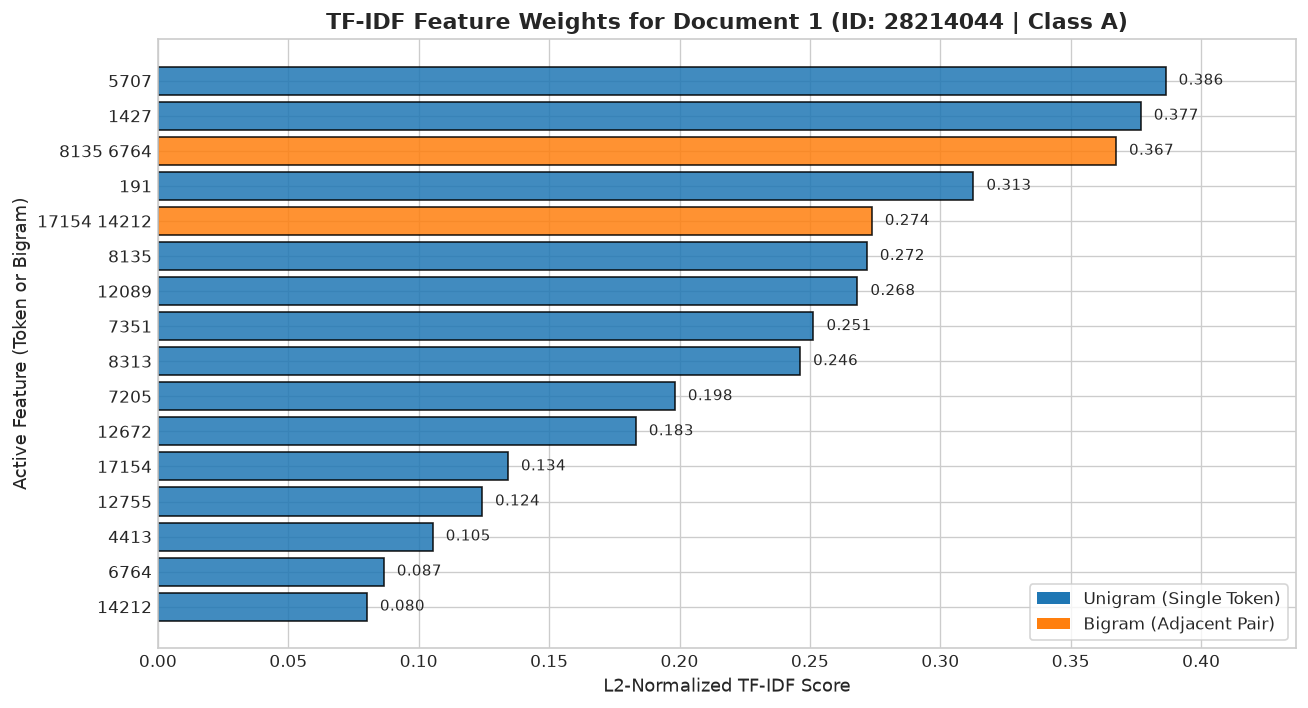

In [4]:
# Extract all active features of the 1st document (Row Index 0)
doc_idx = 0
doc_info = df_sample.iloc[doc_idx]
raw_tokens = doc_info['text']
row_0 = X_real[doc_idx]

non_zero_indices = row_0.indices
non_zero_values = row_0.data
feature_names = np.array(tfidf_real.get_feature_names_out())
idf_weights = tfidf_real.idf_

features_list = []
for col_idx, tfidf_val in zip(non_zero_indices, non_zero_values):
    feat = feature_names[col_idx]
    is_bigram = (' ' in feat)
    feat_type = 'Bigram' if is_bigram else 'Unigram'
    idf = idf_weights[col_idx]
    
    # Count occurrences in document
    if is_bigram:
        w1, w2 = map(int, feat.split())
        count = sum(1 for i in range(len(raw_tokens)-1) if raw_tokens[i] == w1 and raw_tokens[i+1] == w2)
    else:
        w = int(feat)
        count = raw_tokens.count(w)
        
    features_list.append({
        'Vocab Index': col_idx,
        'Feature Token': feat,
        'Type': feat_type,
        'Raw Count (TF)': count,
        'Sublinear TF': 1 + np.log(count) if count > 0 else 0.0,
        'Global IDF': idf,
        'TF-IDF Score': tfidf_val,
        'Energy % (L2)': (tfidf_val ** 2) * 100
    })

df_doc0 = pd.DataFrame(features_list).sort_values(by='TF-IDF Score', ascending=False).reset_index(drop=True)
df_doc0.index = df_doc0.index + 1
df_doc0.index.name = 'Rank'

print('=' * 75)
print('📄 DOCUMENT 1 METADATA:')
print(f"  • Sample ID          : {doc_info['id']}")
print(f"  • True Class Label   : {doc_info['label']} (Human)")
print(f"  • Sequence Length    : {len(raw_tokens)} tokens")
print(f"  • Raw Token Sequence : {raw_tokens}")
print(f"  • Active Features    : {len(df_doc0)} non-zero entries (out of {X_real.shape[1]:,} in global vocabulary)")
print(f"  • Unigrams Active    : {(df_doc0['Type'] == 'Unigram').sum()} | Bigrams Active: {(df_doc0['Type'] == 'Bigram').sum()}")
print(f"  • Sum of Squared L2  : {df_doc0['Energy % (L2)'].sum():.2f}% (confirms perfect unit normalisation)")
print('=' * 75)

print('\n--- ALL 16 ACTIVE TF-IDF FEATURES FOR DOCUMENT 1 ---')
display(df_doc0.style.format({
    'Sublinear TF': '{:.2f}',
    'Global IDF': '{:.4f}',
    'TF-IDF Score': '{:.4f}',
    'Energy % (L2)': '{:.2f}%'
}))

# Visual Bar Chart of Document 1 Features
plt.figure(figsize=(11, 6))
colors = ['#1f77b4' if t == 'Unigram' else '#ff7f0e' for t in df_doc0['Type']]
bars = plt.barh(df_doc0['Feature Token'].astype(str), df_doc0['TF-IDF Score'], color=colors, edgecolor='black', alpha=0.85)
plt.gca().invert_yaxis()  # Highest weight at top
plt.title(f"TF-IDF Feature Weights for Document 1 (ID: {doc_info['id']} | Class {doc_info['label']})", fontsize=13, fontweight='bold')
plt.xlabel('L2-Normalized TF-IDF Score', fontsize=11)
plt.ylabel('Active Feature (Token or Bigram)', fontsize=11)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.005, bar.get_y() + bar.get_height()/2, f'{w:.3f}', va='center', fontsize=9)

legend_elements = [
    Patch(facecolor='#1f77b4', label='Unigram (Single Token)'),
    Patch(facecolor='#ff7f0e', label='Bigram (Adjacent Pair)')
]
plt.legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white', fontsize=10)
plt.xlim(0, max(df_doc0['TF-IDF Score']) + 0.05)
plt.tight_layout()
plt.show()


## 4. Identifying Class-Discriminative Tokens (Human vs. Machine)

How do linear models (such as `LinearSVC` in Model 1) distinguish **Class A (Human)** from **Class B (Machine)** using TF-IDF?

We compute the **Mean TF-IDF difference** for every token across both classes:
$$\Delta \text{TFIDF}(t) = \overline{\text{TFIDF}}_B(t) - \overline{\text{TFIDF}}_A(t)$$

- **Positive $\Delta \text{TFIDF}(t) > 0$:** Signature terms with high salience in **Machine (Class B)** texts.
- **Negative $\Delta \text{TFIDF}(t) < 0$:** Signature terms with high salience in **Human (Class A)** texts.

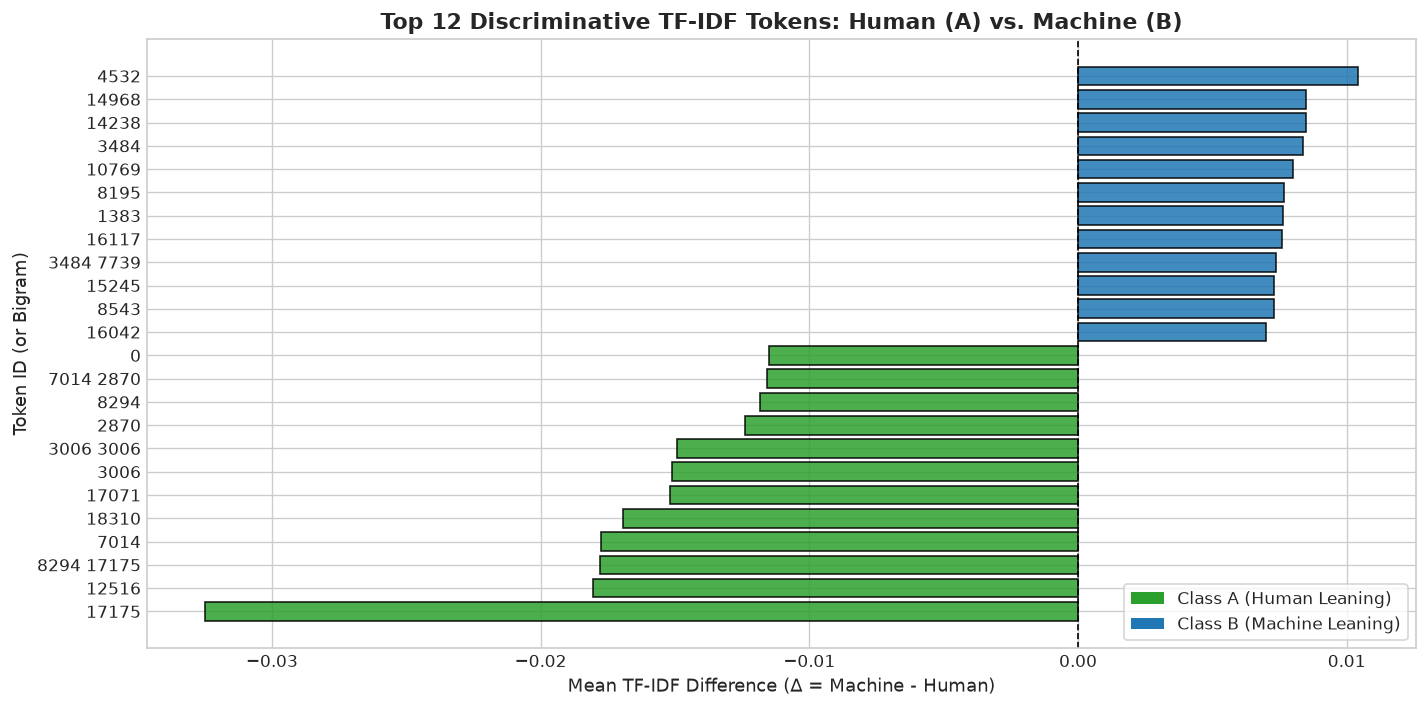

In [5]:
# Separate sparse matrices by class
idx_A = np.where(df_sample['label'].values == 'A')[0]
idx_B = np.where(df_sample['label'].values == 'B')[0]

mean_tfidf_A = np.asarray(X_real[idx_A].mean(axis=0)).ravel()
mean_tfidf_B = np.asarray(X_real[idx_B].mean(axis=0)).ravel()

diff_tfidf = mean_tfidf_B - mean_tfidf_A
real_vocab = np.array(tfidf_real.get_feature_names_out())

# Extract top 12 Human and Machine tokens
top_k = 12
top_machine_idx = np.argsort(diff_tfidf)[-top_k:]
top_human_idx = np.argsort(diff_tfidf)[:top_k]

plot_df = pd.DataFrame({
    'Token': np.concatenate([real_vocab[top_human_idx], real_vocab[top_machine_idx]]),
    'Delta_TFIDF': np.concatenate([diff_tfidf[top_human_idx], diff_tfidf[top_machine_idx]]),
    'Class Leaning': ['Class A (Human)'] * top_k + ['Class B (Machine)'] * top_k
})

plt.figure(figsize=(12, 6))
colors = ['#2ca02c' if c == 'Class A (Human)' else '#1f77b4' for c in plot_df['Class Leaning']]
bars = plt.barh(plot_df['Token'], plot_df['Delta_TFIDF'], color=colors, edgecolor='black', alpha=0.85)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title(f"Top {top_k} Discriminative TF-IDF Tokens: Human (A) vs. Machine (B)", fontsize=13, fontweight='bold')
plt.xlabel("Mean TF-IDF Difference (Δ = Machine - Human)", fontsize=11)
plt.ylabel("Token ID (or Bigram)", fontsize=11)

legend_elements = [
    Patch(facecolor='#2ca02c', label='Class A (Human Leaning)'),
    Patch(facecolor='#1f77b4', label='Class B (Machine Leaning)')
]
plt.legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white', fontsize=10)
plt.tight_layout()
plt.show()


## 5. Matrix Sparsity & Document-to-Document Cosine Similarity

### Memory Advantage of Compressed Sparse Row (CSR)
In real text corpora, any single document uses only a tiny fraction ($<2\%$) of the global vocabulary.
- A **dense** float64 matrix of $10,000 \times 200,000$ requires:
  $$10,000 \times 200,000 \times 8 \text{ bytes} = 16 \text{ Gigabytes of RAM!}$$
- In **Scipy CSR format**, storing only non-zero entries requires **$< 150 \text{ Megabytes}$**!

### Instant Cosine Similarity via Dot Product
Because Scikit-Learn normalizes every row to unit length ($\|\mathbf{x}\|_2 = 1.0$), computing pairwise cosine similarity between all documents requires only **one sparse matrix multiplication**:

$$\mathbf{S} = \mathbf{X} \mathbf{X}^T$$

where entry $S_{i, j} = \mathbf{x}_i \cdot \mathbf{x}_j = \cos(\theta_{i, j}) \in [0, 1]$.

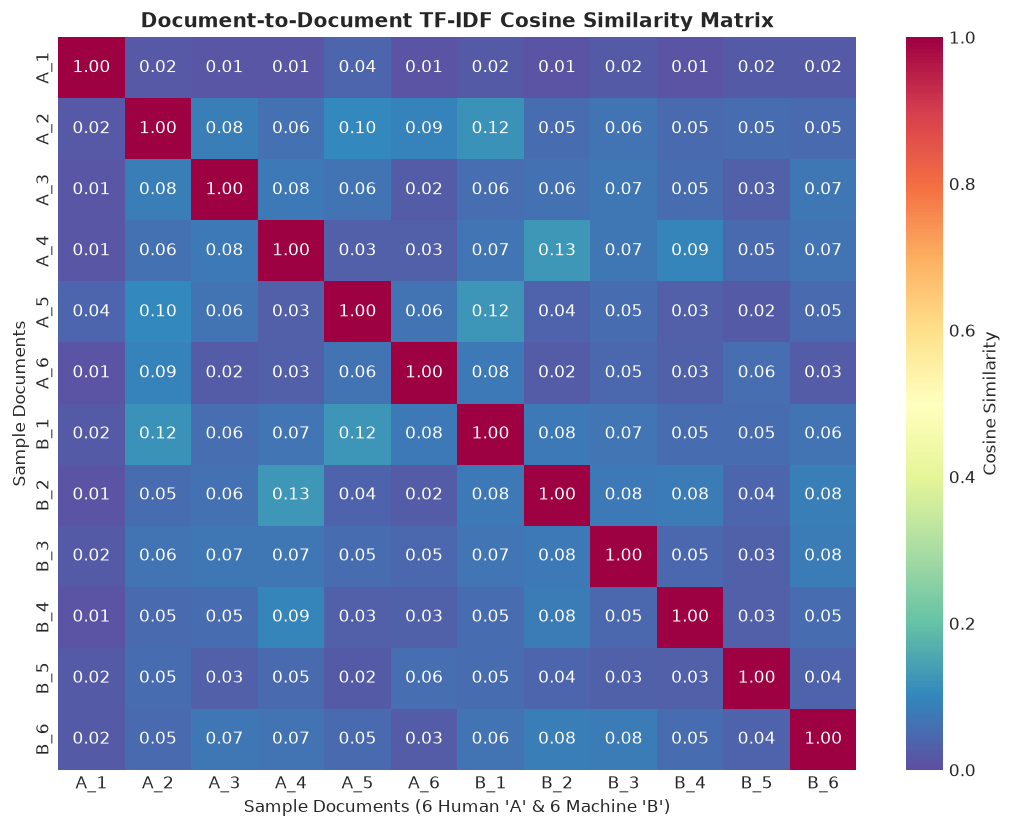

In [6]:
# Select 6 Human and 6 Machine documents
sample_subset_idx = list(range(0, 6)) + list(range(500, 506))
sub_matrix = X_real[sample_subset_idx]
labels_sub = [f"A_{i}" for i in range(1, 7)] + [f"B_{i}" for i in range(1, 7)]

# Pairwise Cosine Similarity: X @ X.T
sim_matrix = (sub_matrix @ sub_matrix.T).toarray()

plt.figure(figsize=(9, 7))
sns.heatmap(
    sim_matrix,
    xticklabels=labels_sub,
    yticklabels=labels_sub,
    annot=True,
    fmt=".2f",
    cmap="Spectral_r",
    vmin=0,
    vmax=1.0,
    cbar_kws={'label': 'Cosine Similarity'}
)
plt.title("Document-to-Document TF-IDF Cosine Similarity Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Sample Documents (6 Human 'A' & 6 Machine 'B')", fontsize=10)
plt.ylabel("Sample Documents", fontsize=10)
plt.tight_layout()
plt.show()


## 6. Summary & Hyperparameter Cheat Sheet for N-Gram Modeling

When tuning `TfidfVectorizer` for competitive NLP and machine learning pipelines, use this reference guide:

| Hyperparameter | Typical Range | Recommended Default | Key Purpose & Best Practice |
| :--- | :---: | :---: | :--- |
| `ngram_range` | `(1, 1)` to `(1, 6)` | `(1, 2)` or `(1, 3)` | Captures single words + adjacent phrasing. Higher n-grams require `min_df` filtering to prevent memory explosion. |
| `sublinear_tf` | `True` / `False` | **`True`** | Replaces linear counts with $1 + \ln(\text{tf})$. Essential for long texts to suppress repetitive word spam. |
| `min_df` | `2` to `10` | **`3` or `5`** | Eliminates rare typo/noise tokens appearing in $< \text{min_df}$ documents, drastically compressing sparse matrix size. |
| `max_df` | `0.7` to `1.0` | **`0.95`** | Prunes corpus-wide stopwords appearing in $> 95\%$ of all documents without needing a manual stopword list. |
| `norm` | `'l2'`, `'l1'`, `None` | **`'l2'`** | Projects documents onto unit hypersphere. Guarantees cosine similarity is simply the dot product $\mathbf{x}_i \mathbf{x}_j^T$. |
| `smooth_idf` | `True` / `False` | **`True`** | Adds $+1$ to numerator and denominator $\ln\frac{1+N}{1+\text{df}} + 1$. Prevents division by zero and zeroed weights. |
| `token_pattern` | Regex string | `r'(?u)\S+'` | Use `\S+` for whitespace-delimited integer tokens (Kaggle format) or standard word boundary `\b\w+\b` for natural text. |

---
*Created inside `Core_Analysis` for the Kaggle Machine Learning Project 1 Research Suite.*